In [1]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import transforms
import torchvision
import torch.optim as optim

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [3]:
train_dataset = torchvision.datasets.MNIST(root="./data",train=True,download=True,transform=transform)
test_dataset = torchvision.datasets.MNIST(root="./data",train=False,download=True,transform=transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 498kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.56MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.85MB/s]


In [4]:
train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=True)

In [6]:
for imag,labels in train_loader:
  break

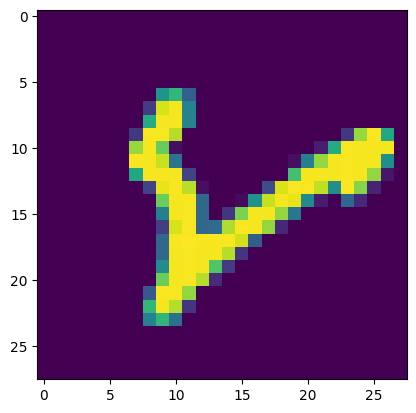

In [11]:
imag.shape
import matplotlib.pyplot as plt
plt.imshow(imag[0].permute(2,1,0))

# Building Autoencoder

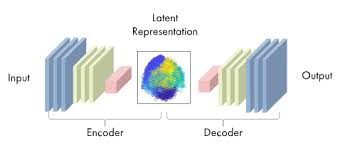

In [13]:
x = imag  # and test batch image
print(x.shape)

torch.Size([32, 1, 28, 28])


In [ ]:
class AutoEncoder(nn.Module):
  def __init__(self,batch_size,in_channels):
    super().__init__()

    pass
  def forward(self,x):
    pass

In [17]:
conv = nn.Conv2d(1,3,3,2)
conv

Conv2d(1, 3, kernel_size=(3, 3), stride=(2, 2))

In [18]:
conv(x).shape
# kernel size = 3x3 , stride = 1
# (n - k)/s + 1

torch.Size([32, 3, 13, 13])

In [26]:
# test encoding
encoding = nn.Sequential(
    nn.Conv2d(1,3,3,1),
    nn.Conv2d(3,6,3,1),
    nn.Conv2d(6,12,3,1),
    nn.Flatten(),
    nn.Linear(12*22*22,3)
)
encoding

Sequential(
  (0): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1))
  (1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (2): Conv2d(6, 12, kernel_size=(3, 3), stride=(1, 1))
  (3): Flatten(start_dim=1, end_dim=-1)
  (4): Linear(in_features=5808, out_features=3, bias=True)
)

In [27]:
encoding(x).shape

torch.Size([32, 3])

In [5]:
class AutoEncoder(nn.Module):
  def __init__(self,latent_dim,in_channels):
    super().__init__()
    self.encoding = nn.Sequential(
        nn.Conv2d(in_channels,12,3,1),
        nn.Conv2d(12,24,3,1),
        nn.Flatten(),
        nn.Linear(24*24*24,latent_dim)
    )
    self.decoder_input = nn.Linear(latent_dim,24*24*24)
    self.decoding = nn.Sequential(
        nn.Unflatten(1,(24,24,24)),
        nn.ConvTranspose2d(24,12,3,1),
        nn.ConvTranspose2d(12,1,3,1),
        nn.Sigmoid()
    )
  def forward(self,x):
    z = self.encoding(x)
    return self.decoding(self.decoder_input(z))

In [6]:
encoder = AutoEncoder(3,1)
encoder

AutoEncoder(
  (encoding): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=13824, out_features=3, bias=True)
  )
  (decoder_input): Linear(in_features=3, out_features=13824, bias=True)
  (decoding): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(24, 24, 24))
    (1): ConvTranspose2d(24, 12, kernel_size=(3, 3), stride=(1, 1))
    (2): ConvTranspose2d(12, 1, kernel_size=(3, 3), stride=(1, 1))
    (3): Sigmoid()
  )
)

In [35]:
encoder(x).shape

torch.Size([32, 1, 28, 28])

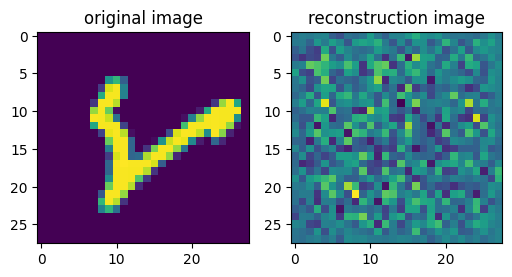

In [42]:
fig,ax = plt.subplots(1,2,figsize=(6,6))
plt.title("No Training")
ax[0].imshow(x[0].permute(2,1,0))
ax[0].set_title("original image")
ax[1].imshow(encoder(x)[0].permute(2,1,0).detach().numpy())
ax[1].set_title("reconstruction image")
plt.show()
# this is random because no loss is calculated

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = AutoEncoder(latent_dim=1, in_channels=1)
model.to(device)

cuda


AutoEncoder(
  (encoding): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=13824, out_features=1, bias=True)
  )
  (decoder_input): Linear(in_features=1, out_features=13824, bias=True)
  (decoding): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(24, 24, 24))
    (1): ConvTranspose2d(24, 12, kernel_size=(3, 3), stride=(1, 1))
    (2): ConvTranspose2d(12, 1, kernel_size=(3, 3), stride=(1, 1))
    (3): Sigmoid()
  )
)

In [11]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [12]:
epochs = 20
model.train() # Set model to training mode

for epoch in range(epochs):
    running_loss = 0.0

    for images, _ in train_loader:
        # Move data to the same device as the model (CPU or GPU)
        images = images.to(device)

        # 1. Forward pass
        reconstructed = model(images)

        # 2. Calculate Loss (Comparing output to original input images)
        loss = criterion(reconstructed, images)

        # 3. Backward pass
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()       # Compute new gradients

        # 4. Optimization step
        optimizer.step()      # Update weights

        running_loss += loss.item()

    # Print average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print("Training Complete!")

Epoch [1/20], Loss: 0.7780
Epoch [2/20], Loss: 0.7549
Epoch [3/20], Loss: 0.7492
Epoch [4/20], Loss: 0.7479
Epoch [5/20], Loss: 0.7471
Epoch [6/20], Loss: 0.7469
Epoch [7/20], Loss: 0.7467
Epoch [8/20], Loss: 0.7466
Epoch [9/20], Loss: 0.7465
Epoch [10/20], Loss: 0.7465
Epoch [11/20], Loss: 0.7463
Epoch [12/20], Loss: 0.7463
Epoch [13/20], Loss: 0.7463
Epoch [14/20], Loss: 0.7462
Epoch [15/20], Loss: 0.7462
Epoch [16/20], Loss: 0.7461
Epoch [17/20], Loss: 0.7461
Epoch [18/20], Loss: 0.7461
Epoch [19/20], Loss: 0.7461
Epoch [20/20], Loss: 0.7460
Training Complete!


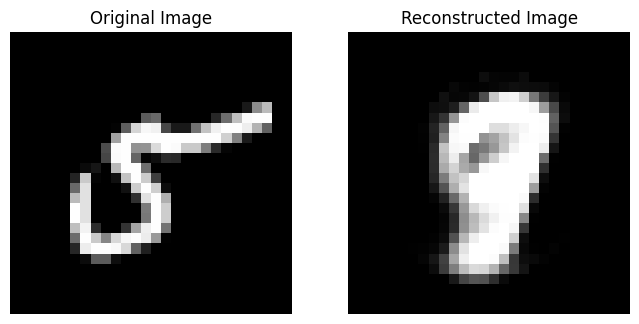

In [13]:
import matplotlib.pyplot as plt

# 1. Set model to evaluation mode
model.eval()

# 2. Get a batch of test images
images, labels = next(iter(test_loader))
images = images.to(device)

# 3. Run inference (no_grad saves memory)
with torch.no_grad():
    reconstructed = model(images)

# 4. Move back to CPU for plotting
images = images.cpu()
reconstructed = reconstructed.cpu()

# 5. Plot the first original and reconstructed image
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original Image
axes[0].imshow(images[0].squeeze(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Reconstructed Image
axes[1].imshow(reconstructed[0].squeeze(), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis('off')

plt.show()

## it is poor because or latent dim = 1

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)
model = AutoEncoder(latent_dim=5, in_channels=1)
model.to(device)

cuda


AutoEncoder(
  (encoding): Sequential(
    (0): Conv2d(1, 12, kernel_size=(3, 3), stride=(1, 1))
    (1): Conv2d(12, 24, kernel_size=(3, 3), stride=(1, 1))
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=13824, out_features=5, bias=True)
  )
  (decoder_input): Linear(in_features=5, out_features=13824, bias=True)
  (decoding): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(24, 24, 24))
    (1): ConvTranspose2d(24, 12, kernel_size=(3, 3), stride=(1, 1))
    (2): ConvTranspose2d(12, 1, kernel_size=(3, 3), stride=(1, 1))
    (3): Sigmoid()
  )
)

In [15]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [16]:
epochs = 20
model.train() # Set model to training mode

for epoch in range(epochs):
    running_loss = 0.0

    for images, _ in train_loader:
        # Move data to the same device as the model (CPU or GPU)
        images = images.to(device)

        # 1. Forward pass
        reconstructed = model(images)

        # 2. Calculate Loss (Comparing output to original input images)
        loss = criterion(reconstructed, images)

        # 3. Backward pass
        optimizer.zero_grad() # Clear previous gradients
        loss.backward()       # Compute new gradients

        # 4. Optimization step
        optimizer.step()      # Update weights

        running_loss += loss.item()

    # Print average loss for the epoch
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

print("Training Complete!")

Epoch [1/20], Loss: 0.6539
Epoch [2/20], Loss: 0.6361
Epoch [3/20], Loss: 0.6346
Epoch [4/20], Loss: 0.6338
Epoch [5/20], Loss: 0.6334
Epoch [6/20], Loss: 0.6331
Epoch [7/20], Loss: 0.6328
Epoch [8/20], Loss: 0.6327
Epoch [9/20], Loss: 0.6325
Epoch [10/20], Loss: 0.6324
Epoch [11/20], Loss: 0.6323
Epoch [12/20], Loss: 0.6322
Epoch [13/20], Loss: 0.6322
Epoch [14/20], Loss: 0.6321
Epoch [15/20], Loss: 0.6320
Epoch [16/20], Loss: 0.6320
Epoch [17/20], Loss: 0.6319
Epoch [18/20], Loss: 0.6319
Epoch [19/20], Loss: 0.6318
Epoch [20/20], Loss: 0.6318
Training Complete!


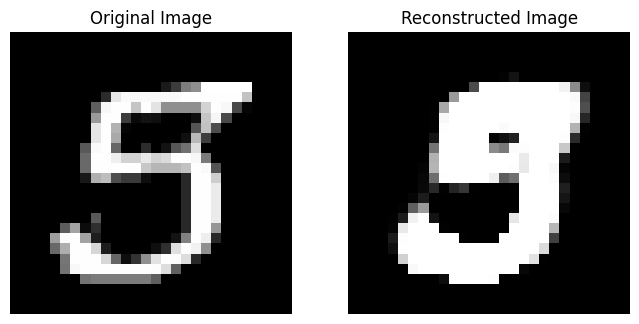

In [17]:
import matplotlib.pyplot as plt

# 1. Set model to evaluation mode
model.eval()

# 2. Get a batch of test images
images, labels = next(iter(test_loader))
images = images.to(device)

# 3. Run inference (no_grad saves memory)
with torch.no_grad():
    reconstructed = model(images)

# 4. Move back to CPU for plotting
images = images.cpu()
reconstructed = reconstructed.cpu()

# 5. Plot the first original and reconstructed image
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Original Image
axes[0].imshow(images[0].squeeze(), cmap='gray')
axes[0].set_title("Original Image")
axes[0].axis('off')

# Reconstructed Image
axes[1].imshow(reconstructed[0].squeeze(), cmap='gray')
axes[1].set_title("Reconstructed Image")
axes[1].axis('off')

plt.show()

## Now it is great just the latent dim is bigest bottleneck but this is deterministic approach i.e no probabilistic approach for sample generation